# Endangered Globe — Data Pipeline

Produces `animals.geojson`: one or more label Points per threatened species, with label, IUCN category, latest assessment metadata, and Wikipedia popularity.

The notebook starts in **sample mode** by default: it reads taxon IDs from the local IUCN spatial packages, then fetches IUCN Red List API v4 details only for those spatially relevant taxa. Switch to `RUN_MODE = "full_mammals"` for mammals, `RUN_MODE = "full_other"` for reptiles/amphibians/crustaceans, `RUN_MODE = "full_fish"` for sharks/rays/chimaeras and freshwater fish, or `RUN_MODE = "full_birds"` for birds.

**Steps**
1. Query latest global IUCN assessments for selected animal classes
2. Compute label points from IUCN habitat polygons or observation points
3. Wikidata SPARQL → Wikipedia article title
4. Wikimedia Pageviews API → 12-month view count
5. Assemble & export GeoJSON

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install requests pandas tqdm geopandas shapely

import importlib
import os, time, json, subprocess, sys
from pathlib import Path
from datetime import date

import requests
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm
from shapely.geometry import mapping
from shapely.ops import unary_union

import scripts.pipeline_helpers as ph
ph = importlib.reload(ph)
from scripts.pipeline_helpers import *


---
## 0 · Configuration

In [2]:
RUN_MODE = "sample_birds"  # one of "sample", "sample_birds", "full_mammals", "full_other", "full_fish", or "full_birds"

IUCN_TOKEN_FILE = Path("data/secrets/iucn_token.txt")
IUCN_TOKEN = os.getenv("IUCN_TOKEN") or read_local_secret(IUCN_TOKEN_FILE)  # Required for both sample and full modes
USER_AGENT = "EndangeredGlobe/1.0 (tdemareuil@gmail.com)"  # Wikimedia requires this

TARGET_CATEGORIES = ["EW", "CR", "EN", "VU", "NT", "CD"]  # CD → displayed as NT
SLEEP_WIKI = 0.15   # seconds between Wikimedia requests
SLEEP_IUCN = 0.5    # IUCN recommends >= 0.5s between calls

OUTPUT_PATH = f"data/processed/animals_{RUN_MODE}.geojson"
MERGED_OUTPUT_PATH = "animals.geojson"
SPATIAL_DATA_DIR = "data/shapefiles"
BIRDS_FILTER_CSV = "data/filters/birds-filter-results.csv"
FULL_BIRDS_SIMPLIFIED = "data/processed/iucn_spatial_clean_full_birds_simplified.geojson"
if RUN_MODE == "sample_birds" and os.path.exists(FULL_BIRDS_SIMPLIFIED):
    CLEAN_SPATIAL_OUTPUT_PATH = FULL_BIRDS_SIMPLIFIED
else:
    CLEAN_SPATIAL_OUTPUT_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson"
CLEAN_SPATIAL_SIMPLIFIED_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}_simplified.geojson"
BIRDS_SIMPLIFY_TOLERANCE = 0.01  # degrees (~1 km); only applied for birds modes
CLEAN_SPATIAL_TARGETS_PATH = f"data/processed/iucn_api_output_{RUN_MODE}.csv"
CLEAN_SPATIAL_PARENT_TARGETS_PATH = "data/processed/iucn_parent_spatial_fallback_taxa.csv"
CLEAN_SPATIAL_PARENT_OUTPUT_PATH = "data/processed/iucn_parent_spatial_fallback.geojson"
IUCN_RED_LIST_VERSION = "2025-2"  # Update if your spatial download uses another Red List version
IUCN_RED_LIST_VERSION_YEAR = "2025"
IUCN_DATA_LAST_UPDATED = "10 October 2025"
SPATIAL_DATA_DOWNLOAD_DATE = "14 June 2026"  # Update to the actual IUCN spatial download date
IUCN_DATASET_CITATION = f"IUCN {IUCN_RED_LIST_VERSION_YEAR}. The IUCN Red List of Threatened Species. Version {IUCN_RED_LIST_VERSION}. https://www.iucnredlist.org. Downloaded on {SPATIAL_DATA_DOWNLOAD_DATE}."
SAMPLE_LIMIT = 200
RUN_SPATIAL_CLEANING = True   # Set to False once iucn_spatial_clean.geojson exists
OVERWRITE_SPATIAL_CLEAN = False  # Set to True only when re-running from fresh raw shapefiles
RUN_IUCN_FETCH = True       # Set to False to reload df from saved CSV and skip the API
MAX_RANGE_CENTROIDS_PER_SPECIES = 2
RANGE_CLUSTER_BUFFER_KM = 200
SECONDARY_RANGE_CLUSTER_MIN_SHARE = 0.1
USE_IUCN_CACHE = True
USE_PARENT_SPATIAL_FALLBACK = False
GLOBAL_SCOPE_CODE = 1

ph.configure(
    IUCN_TOKEN=IUCN_TOKEN,
    USER_AGENT=USER_AGENT,
    TARGET_CATEGORIES=TARGET_CATEGORIES,
    SLEEP_WIKI=SLEEP_WIKI,
    SLEEP_IUCN=SLEEP_IUCN,
    SPATIAL_DATA_DIR=SPATIAL_DATA_DIR,
    SAMPLE_LIMIT=SAMPLE_LIMIT,
    USE_IUCN_CACHE=USE_IUCN_CACHE,
    USE_PARENT_SPATIAL_FALLBACK=USE_PARENT_SPATIAL_FALLBACK,
    BIRDS_FILTER_CSV=BIRDS_FILTER_CSV,
    GLOBAL_SCOPE_CODE=GLOBAL_SCOPE_CODE,
    IUCN_RED_LIST_VERSION=IUCN_RED_LIST_VERSION,
    IUCN_DATASET_CITATION=IUCN_DATASET_CITATION,
    SPATIAL_DATA_DOWNLOAD_DATE=SPATIAL_DATA_DOWNLOAD_DATE,
    IUCN_DATA_LAST_UPDATED=IUCN_DATA_LAST_UPDATED,
)


---
## 1 · Species list

Default sample path: read mammal taxon IDs from the local mammal spatial package, then fetch a small IUCN detail set so test runs stay quick.

Mammal full path: set `RUN_MODE = "full_mammals"` to process taxa present in the local mammal spatial package.

Other full path: set `RUN_MODE = "full_other"` to process taxa present in the local Reptilia, Amphibia, and selected crustacean spatial packages.

Fish full path: set `RUN_MODE = "full_fish"` to process taxa present in the local freshwater fish and sharks/rays/chimaeras spatial packages, without querying broad marine fish classes.

Subspecies nuance: only shapefile taxa with endangered spatial categories are fetched from the API. If one of those fetched/displayable parent species reports threatened infrarank children that are absent from the shapefiles, those children can be displayed while inheriting the parent species geometry as a lookup source.

Ignored edge case for speed and simplicity: a non-threatened parent species whose missing infrarank child is threatened and absent from the shapefiles. We do not fetch LC/DD/NE parent taxa just to search for this case.


### Spatial cleaning

Reads the raw spatial files once, filters to threatened species, applies presence/seasonal filtering, and writes `iucn_spatial_clean.geojson`:
- **Birds**: keeps only taxa listed in the BirdLife filter CSV.
- **All other packages**: keeps only rows with a displayable IUCN category in the shapefile.

Set `RUN_SPATIAL_CLEANING = False` once the file exists and the raw data hasn't changed.

In [3]:
packages = RUN_MODE_SPATIAL_PACKAGES[RUN_MODE]

if RUN_MODE == "sample_birds" and os.path.exists(FULL_BIRDS_SIMPLIFIED):
    print(f"sample_birds: reusing {FULL_BIRDS_SIMPLIFIED}")
elif RUN_SPATIAL_CLEANING:
    if os.path.exists(CLEAN_SPATIAL_OUTPUT_PATH) and not OVERWRITE_SPATIAL_CLEAN:
        print(f"Clean file already exists — skipping to protect it (set OVERWRITE_SPATIAL_CLEAN=True to overwrite): {CLEAN_SPATIAL_OUTPUT_PATH}")
    else:
        ph.run_spatial_prefilter(
            packages=packages,
            output_path=CLEAN_SPATIAL_OUTPUT_PATH,
            birds_filter_csv=BIRDS_FILTER_CSV if "BIRDS" in packages else None,
        )
else:
    print(f"Using existing clean spatial file: {CLEAN_SPATIAL_OUTPUT_PATH}")

sample_birds: reusing data/processed/iucn_spatial_clean_full_birds_simplified.geojson


### Geometry simplification (birds only)

BirdLife polygons are very high-resolution, making the clean file ~6 GB. Since only centroids are needed downstream, simplify to `BIRDS_SIMPLIFY_TOLERANCE` degrees and write to a separate file. Non-bird modes skip this cell.

In [4]:
if "BIRDS" in packages and RUN_MODE != "sample_birds":
    import geopandas as gpd
    os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"
    print(f"Loading {CLEAN_SPATIAL_OUTPUT_PATH} for simplification...")
    gdf_birds = gpd.read_file(CLEAN_SPATIAL_OUTPUT_PATH)
    before_size = os.path.getsize(CLEAN_SPATIAL_OUTPUT_PATH) / 1e6
    gdf_birds["geometry"] = gdf_birds.geometry.simplify(
        BIRDS_SIMPLIFY_TOLERANCE, preserve_topology=True
    )
    gdf_birds = gdf_birds[gdf_birds.geometry.notna() & ~gdf_birds.geometry.is_empty].copy()
    gdf_birds.to_file(CLEAN_SPATIAL_SIMPLIFIED_PATH, driver="GeoJSON")
    after_size = os.path.getsize(CLEAN_SPATIAL_SIMPLIFIED_PATH) / 1e6
    print(f"Simplified: {before_size:.0f} MB → {after_size:.0f} MB ({after_size/before_size*100:.1f}%)")
    print(f"Written: {CLEAN_SPATIAL_SIMPLIFIED_PATH}")
else:
    print("Simplification skipped")

Simplification skipped


### IUCN API call

In [5]:
if not RUN_IUCN_FETCH and os.path.exists(CLEAN_SPATIAL_TARGETS_PATH):
    df = pd.read_csv(CLEAN_SPATIAL_TARGETS_PATH)
    print(f"Loaded {len(df):,} taxa from {CLEAN_SPATIAL_TARGETS_PATH} (API fetch skipped)")
else:
    spatial_manifest = ph.spatial_manifest_from_clean_file(CLEAN_SPATIAL_OUTPUT_PATH, RUN_MODE)
    df = fetch_iucn_species_from_spatial_manifest(spatial_manifest)
    print(f"{RUN_MODE} mode before dedup: {len(df):,} display taxa from IUCN")

df.head()

Spatial manifest from clean file: 200 taxa (sample_birds)


Fetch IUCN from spatial IDs:   0%|          | 0/200 [00:00<?, ?it/s]

IUCN spatial-package fetch summary
- Spatial seed taxa fetched from API: 200
- Display rows kept: 200 (200 direct shapefile taxa + 0 children using parent geometry)
- Missing-spatial child candidates tested from displayable parents: 0
- Missing-spatial children added with parent geometry: 0
- Parent rows not used for child discovery after API validation: 0
- Self rows skipped by shapefile category prefilter: 0
- Child/self rows skipped after API detail: 0 (none)
- Duplicate rows ignored: 0
sample_birds mode before dedup: 200 display taxa from IUCN


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,parent_taxonid,child_infrarank_taxonids,taxon_class,spatial_package,spatial_category,taxon_group,spatial_lookup_taxonid,spatial_lookup_source,iucn_has_ranges,iucn_has_points
0,22678073,219615764,2022-08-12T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678073/2...,BirdLife International 2022. Rhea americana. T...,Rhea americana,Greater Rhea,NT,Decreasing,...,None,[],AVES,BIRDS,None,Birds,22678073,self,True,False
1,22678122,214272214,2022-08-11T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678122/2...,BirdLife International 2022. Apteryx australis...,Apteryx australis,Southern Brown Kiwi,VU,Decreasing,...,None,[],AVES,BIRDS,None,Birds,22678122,self,True,False
2,22678129,214096691,2022-05-30T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678129/2...,BirdLife International 2022. Apteryx owenii. T...,Apteryx owenii,Little Spotted Kiwi,NT,Increasing,...,None,[],AVES,BIRDS,None,Birds,22678129,self,True,False
3,22678132,214091794,2022-08-10T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678132/2...,BirdLife International 2022. Apteryx haastii. ...,Apteryx haastii,Great Spotted Kiwi,VU,Decreasing,...,None,[],AVES,BIRDS,None,Birds,22678132,self,True,False
4,22678135,136638024,2018-10-15T01:00:00.000+01:00,2019,https://www.iucnredlist.org/species/22678135/1...,BirdLife International 2019. Tinamus tao. The ...,Tinamus tao,Grey Tinamou,VU,Decreasing,...,None,[],AVES,BIRDS,None,Birds,22678135,self,True,False


### Species vs. subspecies selection

In [6]:
if RUN_IUCN_FETCH:
    # Parent species removed here are not displayed, but child rows keep parent_taxonid
    # and spatial_lookup_taxonid so later spatial/Wikidata fallbacks can still use the parent.
    print(f"Fetched rows: {len(df):,}; unique taxa: {df.taxonid.nunique():,}")
    
    if "spatial_lookup_source" in df.columns:
        print(df["spatial_lookup_source"].fillna("Unknown").value_counts().to_string())
    
    if {"category", "spatial_category", "spatial_lookup_source"}.issubset(df.columns):
        direct_rows = df[df["spatial_lookup_source"].eq("self")].copy()
        direct_mismatches = direct_rows[direct_rows["category"].fillna("Unknown") != direct_rows["spatial_category"].fillna("Unknown")]
        print(
            f"\nDirect shapefile taxa with API category different from shapefile category: "
            f"{len(direct_mismatches):,} / {len(direct_rows):,}"
        )
        if not direct_mismatches.empty:
            display(
                direct_mismatches[["taxonid", "scientific_name", "main_common_name", "category", "spatial_category"]]
                .head(20)
            )
    
    # Normalise CD -> NT for display, deduplicate on taxonid, then prefer fetched
    # endangered infraranks over their parent species.
    df["category_iucn"] = df["category"].replace("CD", "NT")
    df = df.drop_duplicates(subset="taxonid").copy()
    before_selection = len(df)
    df = replace_species_with_available_infraranks(df)
    removed_parents = before_selection - len(df)
    print(f"\nAfter species vs. subspecies selection: {len(df):,} rows ({removed_parents:,} parent species removed)")
    
    print("\nEndangered category balance after selection:")
    print(df["category_iucn"].value_counts().to_string())
    if "taxon_rank" in df.columns:
        print("\ntaxon_rank after selection:")
        print(df["taxon_rank"].fillna("Unknown").value_counts().to_string())
    if "taxon_group" in df.columns:
        print("\ntaxon_group after selection:")
        print(df["taxon_group"].fillna("Unknown").value_counts().to_string())
    
    df.head()
else:
    print(f"Species/subspecies selection skipped — using saved CSV ({df['taxon_rank'].value_counts().to_string() if 'taxon_rank' in df.columns else ''})")

Fetched rows: 200; unique taxa: 200
spatial_lookup_source
self    200

Direct shapefile taxa with API category different from shapefile category: 200 / 200


,taxonid,scientific_name,main_common_name,category,spatial_category
0,22678073,Rhea americana,Greater Rhea,NT,None
1,22678122,Apteryx australis,Southern Brown Kiwi,VU,None
2,22678129,Apteryx owenii,Little Spotted Kiwi,NT,None
3,22678132,Apteryx haastii,Great Spotted Kiwi,VU,None
4,22678135,Tinamus tao,Grey Tinamou,VU,None
5,22678139,Tinamus solitarius,Solitary Tinamou,NT,None
6,22678145,Tinamus osgoodi,Black Tinamou,VU,None
7,22678151,Tinamus guttatus,White-throated Tinamou,NT,None
8,22678185,Crypturellus transfasciatus,Pale-browed Tinamou,NT,None
9,22678191,Crypturellus boucardi,Slaty-breasted Tinamou,VU,None



After species vs. subspecies selection: 200 rows (0 parent species removed)

Endangered category balance after selection:
category_iucn
NT    78
VU    76
EN    28
CR    17
EW     1

taxon_rank after selection:
taxon_rank
species    200

taxon_group after selection:
taxon_group
Birds    200


### Save API output

In [7]:
os.makedirs(os.path.dirname(CLEAN_SPATIAL_TARGETS_PATH), exist_ok=True)
df.to_csv(CLEAN_SPATIAL_TARGETS_PATH, index=False)
print(f"API output saved: {CLEAN_SPATIAL_TARGETS_PATH} ({len(df):,} rows, {len(df.columns)} columns)")

API output saved: data/processed/iucn_api_output_sample_birds.csv (200 rows, 25 columns)


---
## 2 · IUCN Spatial Data — habitat polygons / observation points → centroids

All run modes use the same spatial step. The difference is which local IUCN spatial packages seed `df`. The heavy source files are cleaned in the previous cell; this section reads the smaller cleaned spatial file.

Rules:
- If a species has one contiguous range polygon, use a centroid-like point inside that shape.
- If a species has multiple disjoint range polygons, group nearby components with the configured `RANGE_CLUSTER_BUFFER_KM`, always keep the largest cluster, then keep secondary clusters only when they pass `SECONDARY_RANGE_CLUSTER_MIN_SHARE`, capped by `MAX_RANGE_CENTROIDS_PER_SPECIES`.
- If a species has no range polygon, fall back to the centroid of its observation points.

Download the relevant animal shapefiles from [IUCN Spatial Data Download](https://www.iucnredlist.org/resources/spatial-data-download) into `data/shapefiles/` before running the cleaning step.

Matching method:
- IUCN API rows use `taxonid` as the species/taxon identifier.
- IUCN spatial files use `id_no` for the same identifier.
- Therefore the spatial join is `spatial.id_no == df.taxonid`, not `assessment_id`.
- Spatial source folders are selected from explicit `spatial_package` values; `taxon_class` is kept only as API metadata.
- This keeps package concepts separate from taxonomy concepts: for example, `FW_FISH` is not the same thing as the whole class `Actinopterygii`.
- Split downloads such as `MAMMALS_PART*.shp` and `FW_FISH_PART*.shp` are chunks of the same spatial package; concatenate them, filter to target `taxonid`s, then dissolve/group by `taxonid`.
- Use `presence` as a strong priority per taxon: Extant, Probably Extant, Possibly Extant, Possibly Extinct, Presence Uncertain, Extinct.
- Ignore `origin` for centroid placement.
- Use `seasonal` as a secondary soft priority per taxon: Resident, then Breeding, then Non-breeding, then Passage, then Seasonality Uncertain.


### Parent species spatial fallback

This cell looks only at parent species from which spatial information will be propagated to displayed subspecies that were not initially present in the spatial files.

Parents remain lookup sources, never additional displayed animals. The fallback is deliberately narrow: it only applies to rows already routed to parent geometry during the IUCN fetch, then copies matched parent polygons/points onto those displayed subspecies.


In [8]:
os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"
# Quick re-filter: keep only taxa confirmed by the IUCN API
target_ids = set(df["taxonid"].astype(int))
spatial_path = CLEAN_SPATIAL_SIMPLIFIED_PATH if os.path.exists(CLEAN_SPATIAL_SIMPLIFIED_PATH) else CLEAN_SPATIAL_OUTPUT_PATH
print(f"Loading spatial file: {spatial_path}")
gdf_all = load_clean_spatial_file(spatial_path)
gdf_all = gdf_all[gdf_all["taxonid"].astype(int).isin(target_ids)].copy()
gdf_all["spatial_lookup_taxonid"] = gdf_all["taxonid"].astype(int)
gdf_all["spatial_lookup_source"] = "self"

if USE_PARENT_SPATIAL_FALLBACK:
    # Parent-species spatial fallback. This intentionally runs after the self-geometry load:
    # we only clean parent geometries for rows already routed to parent geometry in section 1.
    # Parents remain lookup sources, never displayed taxa.
    display_taxa = df.drop_duplicates(subset="taxonid").copy()
    display_taxa["taxonid"] = display_taxa["taxonid"].astype(int)
    display_taxa["parent_taxonid_numeric"] = pd.to_numeric(display_taxa.get("parent_taxonid"), errors="coerce")
    uses_parent_lookup = display_taxa.get("spatial_lookup_source").eq("parent_species") if "spatial_lookup_source" in display_taxa.columns else pd.Series(False, index=display_taxa.index)
    if "spatial_lookup_taxonid" in display_taxa.columns:
        parent_lookup_from_fetch = pd.to_numeric(display_taxa["spatial_lookup_taxonid"], errors="coerce")
        display_taxa.loc[display_taxa["parent_taxonid_numeric"].isna() & uses_parent_lookup, "parent_taxonid_numeric"] = parent_lookup_from_fetch
    self_spatial_taxa = set(gdf_all["taxonid"].astype(int))
    parent_fallback_links = display_taxa[
        display_taxa["parent_taxonid_numeric"].notna()
        & uses_parent_lookup
        & ~display_taxa["taxonid"].isin(self_spatial_taxa)
    ][["taxonid", "parent_taxonid_numeric", "spatial_package"]].drop_duplicates()
    
    if parent_fallback_links.empty:
        pass
    else:
        parent_fallback_links["parent_taxonid"] = parent_fallback_links["parent_taxonid_numeric"].astype(int)
        parent_ids = sorted(parent_fallback_links["parent_taxonid"].unique())
        parent_targets = (
            parent_fallback_links[["parent_taxonid", "spatial_package"]]
            .drop_duplicates()
            .rename(columns={"parent_taxonid": "taxonid"})
        )
        parent_targets["category_iucn"] = None
        parent_targets["scientific_name"] = None
        parent_targets = parent_targets[["taxonid", "spatial_package", "category_iucn", "scientific_name"]]
        parent_targets.to_csv(CLEAN_SPATIAL_PARENT_TARGETS_PATH, index=False)
    
        parent_cleaning_available = os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH)
        if RUN_SPATIAL_CLEANING:
            parent_cleaning_available = False
            try:
                run_spatial_cleaning(CLEAN_SPATIAL_PARENT_TARGETS_PATH, CLEAN_SPATIAL_PARENT_OUTPUT_PATH, SPATIAL_DATA_DIR)
                parent_cleaning_available = True
            except subprocess.CalledProcessError:
                print("Spatial parent fallback: parent cleaning found no usable records or failed; continuing without parent geometries")
        else:
            print(f"Skipping parent spatial cleaning; expecting existing file: {CLEAN_SPATIAL_PARENT_OUTPUT_PATH}")
    
        if parent_cleaning_available and os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH):
            parent_gdf = load_clean_spatial_file(CLEAN_SPATIAL_PARENT_OUTPUT_PATH, parent_ids)
            fallback_frames = []
            for link in parent_fallback_links.itertuples(index=False):
                parent_id = int(link.parent_taxonid)
                child_id = int(link.taxonid)
                parent_rows = parent_gdf[parent_gdf["taxonid"].astype(int) == parent_id].copy()
                if parent_rows.empty:
                    continue
                parent_rows["spatial_lookup_taxonid"] = parent_id
                parent_rows["spatial_lookup_source"] = "parent_species"
                parent_rows["taxonid"] = child_id
                fallback_frames.append(parent_rows)
            if fallback_frames:
                fallback_gdf = gpd.GeoDataFrame(pd.concat(fallback_frames, ignore_index=True), geometry="geometry", crs="EPSG:4326")
                gdf_all = gpd.GeoDataFrame(pd.concat([gdf_all, fallback_gdf], ignore_index=True), geometry="geometry", crs="EPSG:4326")
            else:
                pass


Loading spatial file: data/processed/iucn_spatial_clean_full_birds_simplified.geojson


### Compute label points per species from polygons first, then observation points

In [30]:
if gdf_all.empty:
    raise RuntimeError("No spatial records matched. Check the cleaning output and IUCN taxon IDs.")

gdf_all["taxonid"] = gdf_all["taxonid"].astype(int)

polygon_rows = []
point_rows = []
for row in gdf_all.itertuples(index=False):
    for geom in polygon_parts(row.geometry):
        polygon_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})
    for geom in point_parts(row.geometry):
        point_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})

polygon_gdf = gpd.GeoDataFrame(polygon_rows, geometry="geometry", crs="EPSG:4326") if polygon_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")
point_gdf = gpd.GeoDataFrame(point_rows, geometry="geometry", crs="EPSG:4326") if point_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

polygon_gdf = best_presence_records(polygon_gdf)
polygon_gdf = best_seasonal_records(polygon_gdf)
point_gdf = best_presence_records(point_gdf)
point_gdf = best_seasonal_records(point_gdf)


spatial_meta = (
    gdf_all.groupby("taxonid", as_index=False)
    .agg(
        source_paths=("source_path", lambda s: "; ".join(sorted({str(x) for x in s if pd.notna(x)}))),
        spatial_citation=("spatial_citation", first_non_empty),
        spatial_year=("spatial_year", latest_year),
    )
)
spatial_meta["iucn_dataset_citation"] = IUCN_DATASET_CITATION
spatial_meta["iucn_data_last_updated"] = IUCN_DATA_LAST_UPDATED
spatial_meta["spatial_credit"] = spatial_meta.apply(lambda row: build_spatial_credit(row.spatial_citation, row.spatial_year), axis=1)

if not polygon_gdf.empty:
    range_geometries = polygon_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    range_presence = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    range_seasons = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    range_lookup = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    range_geometries = range_geometries.merge(range_presence, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_seasons, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_lookup, on="taxonid", how="left")
    range_geometries["spatial_presence_label"] = range_geometries["spatial_presence"].map(presence_label)
    range_geometries["spatial_seasonal_label"] = range_geometries["spatial_seasonal"].map(seasonal_label)
else:
    range_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

if not point_gdf.empty:
    point_geometries = point_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    point_presence = point_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    point_seasons = point_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    point_lookup = point_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    point_geometries = point_geometries.merge(point_presence, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_seasons, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_lookup, on="taxonid", how="left")
    point_geometries["spatial_presence_label"] = point_geometries["spatial_presence"].map(presence_label)
    point_geometries["spatial_seasonal_label"] = point_geometries["spatial_seasonal"].map(seasonal_label)
else:
    point_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")


centroid_rows = []
polygon_taxa = set(range_geometries["taxonid"].astype(int)) if not range_geometries.empty else set()

for row in tqdm(range_geometries.itertuples(index=False), total=len(range_geometries), desc="Range polygon centroids"):
    parts = polygon_parts(row.geometry)
    if not parts:
        continue
    cluster_gdf = cluster_range_parts(parts, RANGE_CLUSTER_BUFFER_KM)
    total_components = len(parts)
    total_clusters = len(cluster_gdf)
    computed_range_area_km2 = float(cluster_gdf["cluster_area_km2"].sum())
    ranked_clusters = cluster_gdf.sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
    ranked_clusters["range_cluster_area_share"] = 0.0
    if computed_range_area_km2 > 0:
        ranked_clusters["range_cluster_area_share"] = ranked_clusters["cluster_area_km2"] / computed_range_area_km2
    top_clusters = ranked_clusters[
        (ranked_clusters.index == 0)
        | (ranked_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
    ].head(MAX_RANGE_CENTROIDS_PER_SPECIES)
    for rank, cluster in enumerate(top_clusters.itertuples(index=False), start=1):
        point = safe_centroid(cluster.geometry)
        centroid_rows.append({
            "taxonid": int(row.taxonid),
            "geometry": point,
            "lon": point.x,
            "lat": point.y,
            "centroid_source": "range_polygon",
            "centroid_rank": rank,
            "centroid_count": len(top_clusters),
            "range_component_count": total_components,
            "range_cluster_count": total_clusters,
            "range_cluster_component_count": cluster.cluster_component_count,
            "range_cluster_buffer_km": RANGE_CLUSTER_BUFFER_KM,
            "range_cluster_area_share": float(cluster.range_cluster_area_share),
            "spatial_presence": row.spatial_presence,
            "spatial_presence_label": row.spatial_presence_label,
            "spatial_seasonal": row.spatial_seasonal,
            "spatial_seasonal_label": row.spatial_seasonal_label,
            "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
            "spatial_lookup_source": row.spatial_lookup_source,
            "computed_range_area_km2": computed_range_area_km2,
            "computed_range_component_area_km2": float(cluster.cluster_area_km2),
            "range_component_area_km2": float(cluster.cluster_area_km2),
            "observation_point_count": None,
        })

for row in tqdm(point_geometries.itertuples(index=False), total=len(point_geometries), desc="Fallback point centroids"):
    if int(row.taxonid) in polygon_taxa:
        continue
    points = point_parts(row.geometry)
    if not points:
        continue
    point = unary_union(points).centroid
    centroid_rows.append({
        "taxonid": int(row.taxonid),
        "geometry": point,
        "lon": point.x,
        "lat": point.y,
        "centroid_source": "observation_points",
        "centroid_rank": 1,
        "centroid_count": 1,
        "range_component_count": 0,
        "range_cluster_count": 0,
        "range_cluster_component_count": None,
        "range_cluster_buffer_km": None,
        "range_cluster_area_share": None,
        "spatial_presence": row.spatial_presence,
        "spatial_presence_label": row.spatial_presence_label,
        "spatial_seasonal": row.spatial_seasonal,
        "spatial_seasonal_label": row.spatial_seasonal_label,
        "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
        "spatial_lookup_source": row.spatial_lookup_source,
        "computed_range_area_km2": None,
        "computed_range_component_area_km2": None,
        "range_component_area_km2": None,
        "observation_point_count": len(points),
    })

centroids = gpd.GeoDataFrame(centroid_rows, geometry="geometry", crs="EPSG:4326")
if centroids.empty:
    raise RuntimeError("No range polygons or observation points matched the selected IUCN taxon IDs.")

centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count",
    "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence", "spatial_presence_label",
    "spatial_seasonal", "spatial_seasonal_label",
    "spatial_lookup_taxonid", "spatial_lookup_source",
    "computed_range_area_km2", "computed_range_component_area_km2",
    "range_component_area_km2", "observation_point_count",
]
spatial_meta_cols = [col for col in spatial_meta.columns if col != "taxonid"]
spatial_merge_cols = [col for col in centroid_cols if col != "taxonid"] + spatial_meta_cols
df["taxonid"] = df["taxonid"].astype(int)
df_base = df.drop(columns=spatial_merge_cols, errors="ignore").drop_duplicates(subset="taxonid").copy()
df = df_base.merge(centroids[centroid_cols], on="taxonid", how="inner")
df = df.merge(spatial_meta, on="taxonid", how="left")
print(f"Output label points with spatial data: {len(df):,} from {df.taxonid.nunique():,} species")
secondary = df[df["centroid_rank"].fillna(1).astype(int) > 1]
print(f"Of which, secondary centroid points kept: {len(secondary):,}")


Range polygon centroids:   0%|          | 0/200 [00:00<?, ?it/s]

Fallback point centroids: 0it [00:00, ?it/s]

Output label points with spatial data: 224 from 200 species
Of which, secondary centroid points kept: 24


In [33]:
df.shape

(224, 57)

### Explore taxa that produced several spatial label points

Taxa with several label points: 24


,taxonid,scientific_name,main_common_name,category_iucn,label_points,source,selected_presence,selected_season,components_available,clusters_available,cluster_buffer_km,total_range_area_km2
125,22680427,Clangula hyemalis,Long-tailed Duck,VU,2,range_polygon,Extant,Breeding,6178,3,200,9.491979e+06
122,22680405,Somateria mollissima,Common Eider,NT,2,range_polygon,Extant,Resident,20,8,200,4.668813e+06
102,22679886,Anser erythropus,Lesser White-fronted Goose,VU,2,range_polygon,Extant,Breeding,201,3,200,2.612525e+06
116,22680339,Marmaronetta angustirostris,Marbled Duck,NT,2,range_polygon,Extant,Resident,15,6,200,1.167223e+06
100,22679820,Oxyura maccoa,Maccoa Duck,EN,2,range_polygon,Extant,Resident,9,4,200,1.133745e+06
84,22679440,Pavo muticus,Green Peafowl,EN,2,range_polygon,Extant,Resident,7,3,200,1.114291e+06
124,22680415,Polysticta stelleri,Steller's Eider,VU,2,range_polygon,Extant,Resident,10,3,200,1.106255e+06
108,22680064,Asarcornis scutulata,White-winged Duck,CR,2,range_polygon,Extant,Resident,15,2,200,9.998945e+05
119,22680373,Aythya nyroca,Ferruginous Duck,NT,2,range_polygon,Extant,Resident,23,10,200,8.148278e+05
165,22682433,Anthracoceros coronatus,Malabar Pied Hornbill,NT,2,range_polygon,Extant,Resident,6,2,200,7.537418e+05


Exploring taxonid: 22680427


,taxonid,scientific_name,main_common_name,category_iucn,centroid_rank,centroid_count,centroid_source,lon,lat,computed_range_component_area_km2,computed_range_area_km2,range_component_count,range_cluster_count,range_cluster_component_count,range_cluster_buffer_km,range_cluster_area_share,spatial_presence_label,spatial_seasonal_label
143,22680427,Clangula hyemalis,Long-tailed Duck,VU,1,2,range_polygon,-104.149285,67.402273,6.025165e+06,9.491979e+06,6178,3,5612,200,0.634764,Extant,Breeding
144,22680427,Clangula hyemalis,Long-tailed Duck,VU,2,2,range_polygon,95.804489,69.694246,3.364270e+06,9.491979e+06,6178,3,410,200,0.354433,Extant,Breeding


,cluster_rank,cluster_area_km2,range_cluster_area_share,cluster_component_count,selected_for_label
0,1,6.025165e+06,0.634764,5612,True
1,2,3.364270e+06,0.354433,410,True
2,3,1.025438e+05,0.010803,156,False


,taxonid,raw_polygon_area_km2,spatial_presence_label,spatial_seasonal_label,source_path
27280,22680427,3.277405e+06,Extant,Breeding,BOTW_2025.gpkg
26467,22680427,2.757485e+06,Extant,Breeding,BOTW_2025.gpkg
29712,22680427,5.151112e+05,Extant,Breeding,BOTW_2025.gpkg
25674,22680427,5.018005e+05,Extant,Breeding,BOTW_2025.gpkg
26422,22680427,4.339035e+05,Extant,Breeding,BOTW_2025.gpkg
29780,22680427,2.490626e+05,Extant,Breeding,BOTW_2025.gpkg
27571,22680427,2.203354e+05,Extant,Breeding,BOTW_2025.gpkg
29526,22680427,1.997433e+05,Extant,Breeding,BOTW_2025.gpkg
30941,22680427,1.344090e+05,Extant,Breeding,BOTW_2025.gpkg
25257,22680427,1.101367e+05,Extant,Breeding,BOTW_2025.gpkg


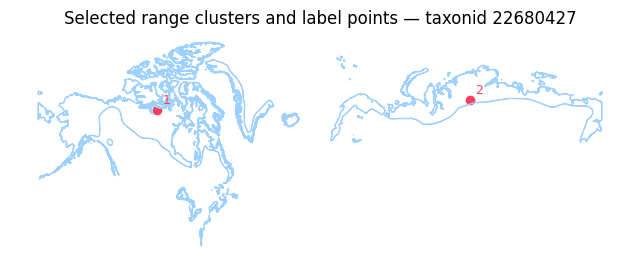

In [35]:
# Set EXPLORE_TAXONID to one taxonid from multi_centroid_summary, or leave None to inspect the first one.
EXPLORE_TAXONID = None
SHOW_EXPLORE_MAP = True

explore_centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence_label", "spatial_seasonal_label",
    "computed_range_area_km2", "computed_range_component_area_km2",
]
missing_centroid_cols = [col for col in explore_centroid_cols if col not in centroids.columns]
if missing_centroid_cols:
    raise RuntimeError(f"Run the spatial centroid cell before this exploration cell. Missing columns: {missing_centroid_cols}")

taxa_for_explore = df.drop(columns=[col for col in explore_centroid_cols if col != "taxonid"], errors="ignore").copy()
taxa_for_explore["taxonid"] = taxa_for_explore["taxonid"].astype(int)
taxa_for_explore = taxa_for_explore.drop_duplicates(subset="taxonid")
explore_df = taxa_for_explore.merge(centroids[explore_centroid_cols], on="taxonid", how="inner")

multi_centroid_summary = (
    explore_df.groupby(["taxonid", "scientific_name", "main_common_name", "category_iucn"], dropna=False)
    .agg(
        label_points=("centroid_rank", "count"),
        source=("centroid_source", first_non_empty),
        selected_presence=("spatial_presence_label", first_non_empty),
        selected_season=("spatial_seasonal_label", first_non_empty),
        components_available=("range_component_count", "max"),
        clusters_available=("range_cluster_count", "max"),
        cluster_buffer_km=("range_cluster_buffer_km", first_non_empty),
        total_range_area_km2=("computed_range_area_km2", "max"),
    )
    .reset_index()
    .query("label_points > 1")
    .sort_values(["label_points", "total_range_area_km2"], ascending=[False, False])
)

print(f"Taxa with several label points: {len(multi_centroid_summary):,}")
display(multi_centroid_summary.head(25))

if multi_centroid_summary.empty:
    print("No taxa with several label points in the current sample.")
else:
    selected_taxonid = int(EXPLORE_TAXONID or multi_centroid_summary.iloc[0].taxonid)
    print(f"Exploring taxonid: {selected_taxonid}")

    selected_points = (
        explore_df[explore_df["taxonid"].astype(int) == selected_taxonid]
        .sort_values("centroid_rank")
        [[
            "taxonid", "scientific_name", "main_common_name", "category_iucn",
            "centroid_rank", "centroid_count", "centroid_source", "lon", "lat",
            "computed_range_component_area_km2", "computed_range_area_km2",
            "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
            "spatial_presence_label", "spatial_seasonal_label",
        ]]
    )
    display(selected_points)

    selected_centroid_geoms = centroids[centroids["taxonid"].astype(int) == selected_taxonid].sort_values("centroid_rank")
    selected_range_geom = range_geometries[range_geometries["taxonid"].astype(int) == selected_taxonid]
    selected_clusters = gpd.GeoDataFrame(columns=["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label", "geometry"], geometry="geometry", crs="EPSG:4326")
    if not selected_range_geom.empty:
        selected_parts = polygon_parts(selected_range_geom.iloc[0].geometry)
        if selected_parts:
            selected_clusters = cluster_range_parts(selected_parts, RANGE_CLUSTER_BUFFER_KM).sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
            selected_clusters["cluster_rank"] = selected_clusters.index + 1
            selected_total_area = selected_clusters["cluster_area_km2"].sum()
            selected_clusters["range_cluster_area_share"] = 0.0
            if selected_total_area > 0:
                selected_clusters["range_cluster_area_share"] = selected_clusters["cluster_area_km2"] / selected_total_area
            selected_clusters["selected_for_label"] = (
                (selected_clusters["cluster_rank"] == 1)
                | (
                    (selected_clusters["cluster_rank"] <= MAX_RANGE_CENTROIDS_PER_SPECIES)
                    & (selected_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
                )
            )
            display(selected_clusters[["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label"]].head(30))
    selected_raw_polygons = polygon_gdf[polygon_gdf["taxonid"].astype(int) == selected_taxonid].copy()
    if not selected_raw_polygons.empty:
        selected_raw_polygons = selected_raw_polygons.copy()
        selected_raw_polygons["raw_polygon_area_km2"] = selected_raw_polygons.to_crs(6933).area / 1e6
        display(
            selected_raw_polygons
            .assign(
                spatial_presence_label=lambda d: d["spatial_presence"].map(presence_label),
                spatial_seasonal_label=lambda d: d["spatial_seasonal"].map(seasonal_label),
            )
            .sort_values("raw_polygon_area_km2", ascending=False)
            [["taxonid", "raw_polygon_area_km2", "spatial_presence_label", "spatial_seasonal_label", "source_path"]]
            .head(30)
        )

    if SHOW_EXPLORE_MAP:
        ax = selected_range_geom.boundary.plot(figsize=(8, 5), color="#4b6fff", linewidth=0.45)
        if not selected_clusters.empty:
            selected_clusters.boundary.plot(ax=ax, color="#9bd0ff", linewidth=1.0)
        selected_centroid_geoms.plot(ax=ax, color="#ff3d5a", markersize=35)
        for row in selected_centroid_geoms.itertuples(index=False):
            ax.annotate(str(row.centroid_rank), (row.lon, row.lat), xytext=(4, 4), textcoords="offset points", color="#ff3d5a", fontsize=9)
        ax.set_title(f"Selected range clusters and label points — taxonid {selected_taxonid}")
        ax.set_axis_off()


In [36]:
df.shape

(224, 57)

---
## 3 · Wikidata SPARQL — IUCN ID → Wikipedia article title

Both modes query Wikidata from IUCN taxon IDs. In sample mode, the batch is simply much smaller.

In [37]:
print("Wikidata language priority:", ", ".join(WIKIPEDIA_LANGUAGE_PRIORITY))


Wikidata language priority: en, de, ja, fr, es, ru, it, zh, pt, pl, nl, uk, ca, sv, cs, fi, ko, tr, no, da, eo


In [38]:
wikidata_taxon_ids = df["taxonid"].drop_duplicates().tolist()
wikidata_map = query_wikidata_batch(wikidata_taxon_ids)

# Name-based fallback: taxa whose IUCN taxon ID isn't linked in Wikidata
# (e.g. Catopuma temminckii stored as Pardofelis temminckii, or missing P627)
unresolved_ids = [t for t in wikidata_taxon_ids if str(t) not in wikidata_map]
if unresolved_ids:
    name_fallback = ph.query_wikidata_by_names(unresolved_ids, df)
    wikidata_map.update(name_fallback)

ph.configure(wikidata_map=wikidata_map)
print(f"Wikipedia articles found: {len(wikidata_map):,} / {len(wikidata_taxon_ids):,} taxa")
print(f"Raw Wikidata P18 images found before map-image filtering: {sum(1 for item in wikidata_map.values() if item.get('wikidata_image_url')):,}")
pd.Series([item.get("wiki_language") for item in wikidata_map.values()]).value_counts().head(10)


Wikidata batches:   0%|          | 0/1 [00:00<?, ?it/s]

Wikidata name fallback: 5 unresolved taxa → 5 P225 candidates
  [1/5] Speculanas specularis ... found
  [2/5] Picoides ramsayi ... found
  [3/5] Dendropicos dorae ... found
  [4/5] Hylatomus schulzii ... found
  [5/5] Nystactes noanamae ... found
  Resolved:
    Speculanas specularis  →  Bronze-winged_duck  |  https://www.wikidata.org/entity/Q913156  |  https://en.wikipedia.org/wiki/Bronze-winged_duck
    Picoides ramsayi  →  Sulu_pygmy_woodpecker  |  https://www.wikidata.org/entity/Q27074878  |  https://en.wikipedia.org/wiki/Sulu_pygmy_woodpecker
    Dendropicos dorae  →  Arabian_woodpecker  |  https://www.wikidata.org/entity/Q27074884  |  https://en.wikipedia.org/wiki/Arabian_woodpecker
    Hylatomus schulzii  →  Black-bodied_woodpecker  |  https://www.wikidata.org/entity/Q1262760  |  https://en.wikipedia.org/wiki/Black-bodied_woodpecker
    Nystactes noanamae  →  Sooty-capped_puffbird  |  https://www.wikidata.org/entity/Q617131  |  https://en.wikipedia.org/wiki/Sooty-capped_puffbird

en    200
Name: count, dtype: int64

### Parent species Wikidata fallback

Wikipedia coverage is often at species level even when IUCN assesses a threatened subspecies. To avoid dropping those subspecies just because Wikidata/Wikipedia has no infrarank article, the notebook uses a parent-species lookup only when needed.

The displayed taxon stays the infrarank taxon: IUCN status, name, assessment URL, and spatial point remain tied to the displayed row. Only the article/image/pageviews lookup can be inherited from the parent. Parent IDs are queried only if they are missing from the local Wikidata cache, and the parent is never added as a displayed animal.

Rows using a parent article or pageview signal are marked with `wiki_lookup_source = "parent_species"`. Rows using only a parent image are marked separately with `image_lookup_source = "parent_species"`.


In [ ]:
# Attach wiki title and Wikidata P18 image.
# If an infrarank taxon has no Wikipedia article, use its parent species as the
# Wikidata/Wikipedia/pageviews/image lookup source while keeping the displayed
# IUCN taxon and conservation status unchanged.
df["wiki_lookup_taxonid"] = df["taxonid"].astype(int)
df["wiki_lookup_source"] = "self"
attach_wikidata_fields(df, wikidata_map)

parent_taxonid_numeric = pd.to_numeric(df.get("parent_taxonid"), errors="coerce")
missing_self_wiki = df["wiki_title"].isna() & parent_taxonid_numeric.notna()
parent_wiki_ids = sorted(parent_taxonid_numeric[missing_self_wiki].dropna().astype(int).unique())
parent_wiki_ids_to_query = [taxonid for taxonid in parent_wiki_ids if str(taxonid) not in wikidata_map]
if parent_wiki_ids_to_query:
    parent_wikidata_map = query_wikidata_batch(parent_wiki_ids_to_query)
    wikidata_map.update(parent_wikidata_map)

parent_has_wiki = parent_taxonid_numeric.map(lambda taxonid: bool((wikidata_map.get(str(int(taxonid))) or {}).get("wiki_title")) if pd.notna(taxonid) else False)
parent_wiki_fallback = missing_self_wiki & parent_has_wiki
if parent_wiki_fallback.any():
    df.loc[parent_wiki_fallback, "wiki_lookup_taxonid"] = parent_taxonid_numeric[parent_wiki_fallback].astype(int)
    df.loc[parent_wiki_fallback, "wiki_lookup_source"] = "parent_species"
    attach_wikidata_fields(df, wikidata_map)

missing_wiki_taxa = (
    df[df["wiki_title"].isna()]
    .drop_duplicates(subset="taxonid")
    [["taxonid", "parent_taxonid", "scientific_name", "main_common_name", "category_iucn"]]
    .sort_values("taxonid")
)
df_wiki = df.dropna(subset=["wiki_title"]).copy()
print(f"Rows with a Wikidata-resolved Wikipedia article: {len(df_wiki):,} label points from {df_wiki.taxonid.nunique():,} taxa")
print(f"Taxa using parent-species Wikipedia fallback: {df_wiki[df_wiki['wiki_lookup_source'] == 'parent_species'].taxonid.nunique():,}")
print(f"Taxa without a Wikidata-resolved Wikipedia article after parent fallback: {len(missing_wiki_taxa):,}")
display(missing_wiki_taxa.head(20))


Rows with a Wikidata-resolved Wikipedia article: 224 label points from 200 taxa
Taxa using parent-species Wikipedia fallback: 0
Taxa without a Wikidata-resolved Wikipedia article after parent fallback: 0


,taxonid,parent_taxonid,scientific_name,main_common_name,category_iucn


TypeError: 'tuple' object is not callable

In [40]:
df_wiki.shape

(224, 57)

In [41]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("nictitans")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,computed_range_area_km2,computed_range_component_area_km2,range_component_area_km2,observation_point_count,source_paths,spatial_citation,spatial_year,iucn_dataset_citation,iucn_data_last_updated,spatial_credit


In [42]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("latebricola")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,computed_range_area_km2,computed_range_component_area_km2,range_component_area_km2,observation_point_count,source_paths,spatial_citation,spatial_year,iucn_dataset_citation,iucn_data_last_updated,spatial_credit


---
## 4 · Wikimedia Pageviews API — 12-month view count

Endpoint: `https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{project}/{access}/{agent}/{article}/monthly/{start}/{end}`

We use the last 12 completed months and sum the monthly totals.

In [ ]:
# Last 12 completed months. Wikimedia's monthly endpoint expects YYYYMMDD.
today = date.today()
current_month_start = date(today.year, today.month, 1)
start_month = date(current_month_start.year - 1, current_month_start.month, 1)
if current_month_start.month == 1:
    end_month = date(current_month_start.year - 1, 12, 1)
else:
    end_month = date(current_month_start.year, current_month_start.month - 1, 1)
START = start_month.strftime("%Y%m01")
END = end_month.strftime("%Y%m01")
PAGEVIEW_MONTHS = (end_month.year - start_month.year) * 12 + end_month.month - start_month.month + 1
ph.set_pageview_window(START, END)

print(f"Pageview window: {START} → {END} inclusive ({PAGEVIEW_MONTHS} monthly buckets)")

# Run once per unique article, then map back to each output label point.
article_keys = df_wiki[["wiki_project", "wiki_title"]].drop_duplicates()
pageview_map = {}
for row in tqdm(article_keys.itertuples(index=False), total=len(article_keys), desc="Pageviews"):
    _views = get_pageviews(row.wiki_project, row.wiki_title)
    pageview_map[(row.wiki_project, row.wiki_title)] = _views
    tqdm.write(f"  {_views:>7,}  {row.wiki_title}")
    time.sleep(SLEEP_WIKI)

df_wiki["popularity"] = df_wiki.apply(lambda row: pageview_map.get((row.wiki_project, row.wiki_title), 0), axis=1).astype(int)


# If a subspecies has its own article but no pageviews in the selected window,
# use the parent species article/pageviews when available. This keeps parent calls narrow.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
zero_pageviews_with_parent = df_wiki["popularity"].eq(0) & df_wiki_parent_taxonid.notna()
if zero_pageviews_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[zero_pageviews_with_parent])
    parent_pageviews = {}
    for parent_id in sorted(df_wiki_parent_taxonid[zero_pageviews_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        if not entry.get("wiki_title"):
            continue
        key = (entry.get("wiki_project"), entry.get("wiki_title"))
        if key not in pageview_map:
            pageview_map[key] = get_pageviews(*key)
            time.sleep(SLEEP_WIKI)
        parent_pageviews[parent_id] = pageview_map.get(key, 0)
    parent_popularity = df_wiki_parent_taxonid.map(lambda taxonid: parent_pageviews.get(int(taxonid), 0) if pd.notna(taxonid) else 0)
    parent_pageview_fallback = zero_pageviews_with_parent & (parent_popularity > 0)
    if parent_pageview_fallback.any():
        apply_wikidata_entry_to_mask(df_wiki, parent_pageview_fallback, df_wiki_parent_taxonid, "parent_species")
        df_wiki.loc[parent_pageview_fallback, "popularity"] = parent_popularity[parent_pageview_fallback].astype(int)
        print(f"Parent-species pageview fallback applied: {df_wiki.loc[parent_pageview_fallback, 'taxonid'].nunique():,} taxa")

# Diagnose zero-popularity taxa (redirect titles, 404s, or genuinely no traffic)
zero_pop = df_wiki[df_wiki["popularity"] == 0].drop_duplicates(subset="taxonid")
if not zero_pop.empty:
    print(f"Zero-popularity taxa: {len(zero_pop):,}")
    for _, _r in zero_pop[["scientific_name", "wiki_title", "wiki_language", "wiki_url"]].iterrows():
        print(f"  {_r['scientific_name']} | {_r['wiki_language']} | {_r['wiki_title']} | {_r['wiki_url']}")

# Prefer Wikidata P18 images. Query Wikipedia thumbnails once per unique article,
# then Commons once per unique taxon, and map results back to all duplicate label points.
wikidata_map_like = df_wiki["wikidata_image_url"].map(is_probable_range_map_title)
excluded_wikidata_image_taxa = df_wiki.loc[wikidata_map_like, "taxonid"].nunique()
if excluded_wikidata_image_taxa:
    for _, _r in df_wiki.loc[wikidata_map_like, ["scientific_name", "wikidata_image_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikidata_image_url']}")
df_wiki.loc[wikidata_map_like, "wikidata_image_url"] = None
print(f"Map-like Wikidata P18 images excluded before thumbnail fallback: {excluded_wikidata_image_taxa:,} taxa")

thumbnail_map = {}
missing_image_articles = df_wiki.loc[df_wiki["wikidata_image_url"].isna(), ["wiki_project", "wiki_title"]].drop_duplicates()
print(f"Wikipedia thumbnail fallback requests: {len(missing_image_articles):,} unique articles")
for row in tqdm(missing_image_articles.itertuples(index=False), total=len(missing_image_articles), desc="Wikipedia thumbnails"):
    thumbnail_map[(row.wiki_project, row.wiki_title)] = get_wikipedia_thumbnail(row.wiki_project, row.wiki_title)
    time.sleep(SLEEP_WIKI)

df_wiki["wikipedia_thumbnail_url"] = df_wiki.apply(lambda row: thumbnail_map.get((row.wiki_project, row.wiki_title)), axis=1)
wikipedia_map_like = df_wiki["wikipedia_thumbnail_url"].map(is_probable_range_map_title)
excluded_wikipedia_image_taxa = df_wiki.loc[wikipedia_map_like, "taxonid"].nunique()
if excluded_wikipedia_image_taxa:
    for _, _r in df_wiki.loc[wikipedia_map_like, ["scientific_name", "wikipedia_thumbnail_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikipedia_thumbnail_url']}")
df_wiki.loc[wikipedia_map_like, "wikipedia_thumbnail_url"] = None

commons_map = {}
missing_thumbnail_taxa = df_wiki.loc[
    df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna(),
    ["taxonid", "scientific_name", "main_common_name"]
].drop_duplicates(subset="taxonid")
for row in tqdm(missing_thumbnail_taxa.itertuples(index=False), total=len(missing_thumbnail_taxa), desc="Commons images"):
    commons_map[str(row.taxonid)] = search_commons_image(row.scientific_name, row.main_common_name)
    time.sleep(SLEEP_WIKI)

commons_fields = [
    "commons_image_url", "commons_image_page_url", "commons_image_title", "commons_image_author",
    "commons_image_license", "commons_image_license_url", "commons_image_credit",
    "commons_image_search_source", "commons_image_search_term",
]
for field in commons_fields:
    df_wiki[field] = df_wiki["taxonid"].astype(str).map(lambda taxonid: (commons_map.get(taxonid) or {}).get(field))

df_wiki["image_url"] = df_wiki["wikidata_image_url"].fillna(df_wiki["wikipedia_thumbnail_url"]).fillna(df_wiki["commons_image_url"])
df_wiki["image_source"] = None
df_wiki.loc[df_wiki["wikidata_image_url"].notna(), "image_source"] = "Wikidata P18"
df_wiki.loc[df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].notna(), "image_source"] = "Wikipedia thumbnail"
df_wiki.loc[df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["commons_image_url"].notna(), "image_source"] = "Wikimedia Commons search"
df_wiki["image_lookup_taxonid"] = pd.to_numeric(df_wiki["wiki_lookup_taxonid"], errors="coerce")
df_wiki["image_lookup_source"] = df_wiki["wiki_lookup_source"]

# If every direct image fallback failed for an infrarank taxon, try the parent species image
# without changing the displayed taxon identity. Only image-missing rows trigger this work.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
missing_image_with_parent = df_wiki["image_url"].isna() & df_wiki_parent_taxonid.notna()
if missing_image_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[missing_image_with_parent])
    parent_image_map = {}
    for parent_id in sorted(df_wiki_parent_taxonid[missing_image_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        parent_wikidata_image = entry.get("wikidata_image_url")
        if is_probable_range_map_title(parent_wikidata_image):
            parent_wikidata_image = None
        parent_thumbnail = None
        if not parent_wikidata_image and entry.get("wiki_project") and entry.get("wiki_title"):
            parent_thumbnail = get_wikipedia_thumbnail(entry.get("wiki_project"), entry.get("wiki_title"))
            time.sleep(SLEEP_WIKI)
            if is_probable_range_map_title(parent_thumbnail):
                parent_thumbnail = None
        parent_image_map[parent_id] = {
            "wikidata_image_url": parent_wikidata_image,
            "wikipedia_thumbnail_url": parent_thumbnail,
        }

    parent_image_url = df_wiki_parent_taxonid.map(
        lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url")
        or (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url")
    )
    parent_image_fallback = missing_image_with_parent & parent_image_url.notna()
    if parent_image_fallback.any():
        parent_wikidata_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url"))
        parent_thumbnail_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url"))
        df_wiki.loc[parent_image_fallback, "wikidata_image_url"] = parent_wikidata_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "wikipedia_thumbnail_url"] = parent_thumbnail_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_url"] = parent_image_url[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_lookup_taxonid"] = df_wiki_parent_taxonid[parent_image_fallback].astype(int)
        df_wiki.loc[parent_image_fallback, "image_lookup_source"] = "parent_species"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.notna(), "image_source"] = "Parent species Wikidata P18"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.isna() & parent_thumbnail_values.notna(), "image_source"] = "Parent species Wikipedia thumbnail"
        print(f"Parent-species image fallback applied: {df_wiki.loc[parent_image_fallback, 'taxonid'].nunique():,} taxa")

image_taxa = df_wiki.drop_duplicates(subset="taxonid")
print(f"Map-like Wikipedia thumbnail images excluded: {excluded_wikipedia_image_taxa:,} taxa")
print(f"Commons fallback images found: {image_taxa.commons_image_url.notna().sum():,} taxa")
print(f"Images found: {image_taxa.image_url.notna().sum():,} / {len(image_taxa):,} taxa ({df_wiki.image_url.notna().sum():,} label points)")


Pageview window: 20250601 → 20260501 inclusive (12 monthly buckets)


Pageviews:   0%|          | 0/200 [00:00<?, ?it/s]

   78,712  Greater_rhea
   17,113  Southern_brown_kiwi
   35,954  Little_spotted_kiwi
   23,512  Great_spotted_kiwi
    2,978  Grey_tinamou
    4,135  Solitary_tinamou
    2,791  Black_tinamou
    2,912  White-throated_tinamou
    2,320  Pale-browed_tinamou
    2,850  Slaty-breasted_tinamou
    2,610  Choco_tinamou
    2,547  Yellow-legged_tinamou
    2,334  Taczanowski's_tinamou
    2,599  Lesser_nothura
    4,509  Dwarf_tinamou
    1,853  Rufous-headed_chachalaca
    2,366  Bearded_guan
    2,211  Baudo_guan
    2,920  Rusty-margined_guan
    9,658  Crested_guan
    2,693  Cauca_guan
    5,602  White-winged_guan
    2,099  White-crested_guan
    2,254  Chestnut-bellied_guan
    1,950  White-browed_guan
    4,388  Trinidad_piping_guan
    1,948  Red-throated_piping_guan
    4,186  Black-fronted_piping_guan
    3,245  Highland_guan
    9,705  Horned_guan
    3,832  Razor-billed_curassow
   40,020  Alagoas_curassow
    6,786  Helmeted_curassow
   28,227  Great_curassow
    6,746  Blue-b

Wikipedia thumbnails:   0%|          | 0/7 [00:00<?, ?it/s]

  Crypturellus kerriae: https://upload.wikimedia.org/wikipedia/commons/thumb/d/d2/Crypturellus_kerriae_map.svg/1280px-Crypturellus_kerriae_map.svg.png
  Penelope purpurascens: https://upload.wikimedia.org/wikipedia/commons/8/8a/Crested_guan_%28Penelope_purpurascens_purpurascens%29_Orange_Walk.jpg
  Pternistis harwoodi: https://upload.wikimedia.org/wikipedia/commons/thumb/5/54/Harwood%27s_spurfowl_distribution_map.svg/1920px-Harwood%27s_spurfowl_distribution_map.svg.png
  Pternistis camerunensis: https://upload.wikimedia.org/wikipedia/commons/thumb/2/2b/Mount_Cameroon_spurfowl_distribution_map.svg/1920px-Mount_Cameroon_spurfowl_distribution_map.svg.png
  Arborophila davidi: https://upload.wikimedia.org/wikipedia/commons/thumb/9/9d/Orange-necked_Partridge_0A2A0860.jpg/3840px-Orange-necked_Partridge_0A2A0860.jpg
  Picumnus varzeae: https://upload.wikimedia.org/wikipedia/commons/4/47/Picumnus_varzeae_-_Varzea_Piculet_%28male%29_Itacoatiara%2C_Amazonas%2C_Brazil.jpg


Commons images:   0%|          | 0/6 [00:00<?, ?it/s]

Map-like Wikipedia thumbnail images excluded: 6 taxa
Commons fallback images found: 2 taxa
Images found: 196 / 200 taxa (220 label points)


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,image_lookup_taxonid,image_lookup_source
0,22678073,219615764,2022-08-12T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678073/2...,BirdLife International 2022. Rhea americana. T...,Rhea americana,Greater Rhea,NT,Decreasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,22678073,self
1,22678122,214272214,2022-08-11T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678122/2...,BirdLife International 2022. Apteryx australis...,Apteryx australis,Southern Brown Kiwi,VU,Decreasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,22678122,self
2,22678129,214096691,2022-05-30T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678129/2...,BirdLife International 2022. Apteryx owenii. T...,Apteryx owenii,Little Spotted Kiwi,NT,Increasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,22678129,self
3,22678129,214096691,2022-05-30T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678129/2...,BirdLife International 2022. Apteryx owenii. T...,Apteryx owenii,Little Spotted Kiwi,NT,Increasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,22678129,self
4,22678132,214091794,2022-08-10T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/22678132/2...,BirdLife International 2022. Apteryx haastii. ...,Apteryx haastii,Great Spotted Kiwi,VU,Decreasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,22678132,self


In [49]:
df_wiki.shape

(224, 72)

In [50]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("nictitans")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,image_lookup_taxonid,image_lookup_source


In [51]:
# sanity check
df_wiki[df_wiki.image_url.fillna('').str.contains("area")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,image_lookup_taxonid,image_lookup_source


In [52]:
df_wiki[['scientific_name','main_common_name','wiki_url', 'wikidata_url','image_url','popularity']].tail()

,scientific_name,main_common_name,wiki_url,wikidata_url,image_url,popularity
219,Harpactes orrhophaeus,Cinnamon-rumped Trogon,https://en.wikipedia.org/wiki/Cinnamon-rumped_...,https://www.wikidata.org/entity/Q1273566,https://commons.wikimedia.org/wiki/Special:Fil...,1936
220,Harpactes duvaucelii,Scarlet-rumped Trogon,https://en.wikipedia.org/wiki/Scarlet-rumped_t...,https://www.wikidata.org/entity/Q1261673,https://commons.wikimedia.org/wiki/Special:Fil...,3339
221,Eurystomus azureus,Azure Dollarbird,https://en.wikipedia.org/wiki/Azure_dollarbird,https://www.wikidata.org/entity/Q1042062,https://commons.wikimedia.org/wiki/Special:Fil...,2741
222,Brachypteracias leptosomus,Short-legged Ground-roller,https://en.wikipedia.org/wiki/Short-legged_gro...,https://www.wikidata.org/entity/Q1190023,https://commons.wikimedia.org/wiki/Special:Fil...,2769
223,Geobiastes squamiger,Scaly Ground-roller,https://en.wikipedia.org/wiki/Scaly_ground_roller,https://www.wikidata.org/entity/Q768358,https://commons.wikimedia.org/wiki/Special:Fil...,2094


### Distribution plots

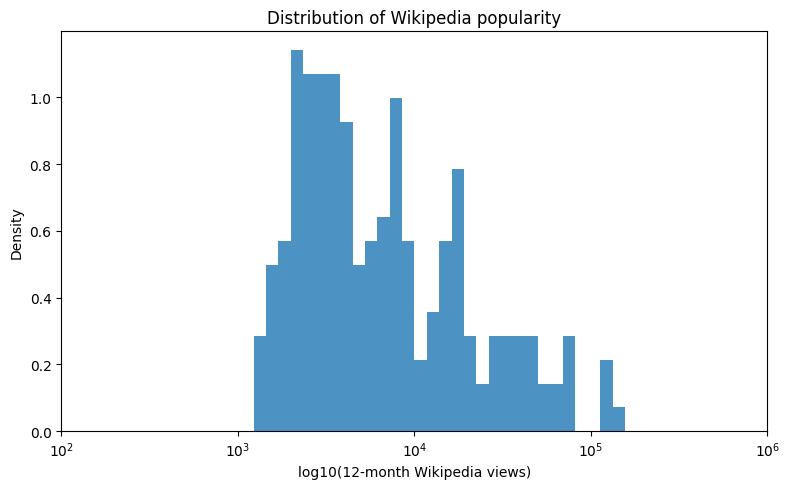

In [21]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

log_views = np.log10(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    log_views,
    bins=30,
    density=True,
    alpha=0.8,
)

ax.set_xlabel("log10(12-month Wikipedia views)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Wikipedia popularity")

# nicer tick labels
ticks = [2, 3, 4, 5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([f"$10^{t}$" for t in ticks])

plt.tight_layout()
plt.show()

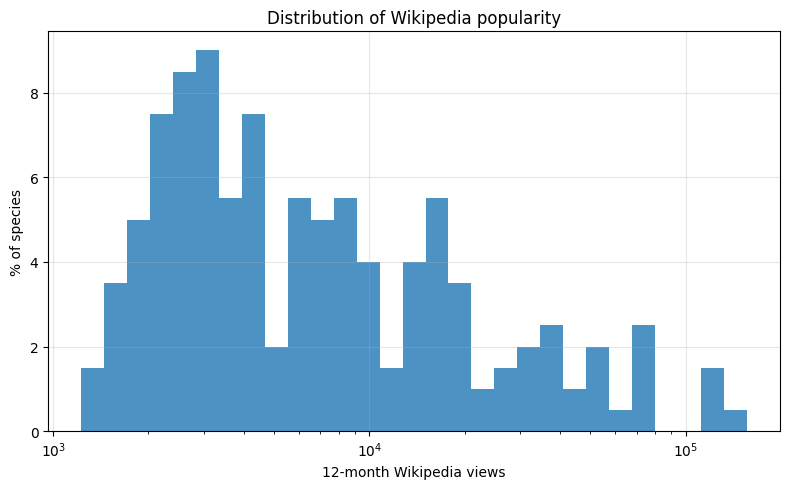

In [22]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

bins = np.logspace(
    np.log10(popularity.min()),
    np.log10(popularity.max()),
    30
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    popularity,
    bins=bins,
    weights=np.full(len(popularity), 100 / len(popularity)),
    alpha=0.8,
)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("% of species")
ax.set_title("Distribution of Wikipedia popularity")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

count       200.000000
mean      13793.015000
std       22470.809493
min        1228.000000
50%        5301.500000
75%       14297.250000
90%       36009.700000
95%       57247.950000
99%      119579.720000
max      156063.000000
Name: popularity, dtype: float64


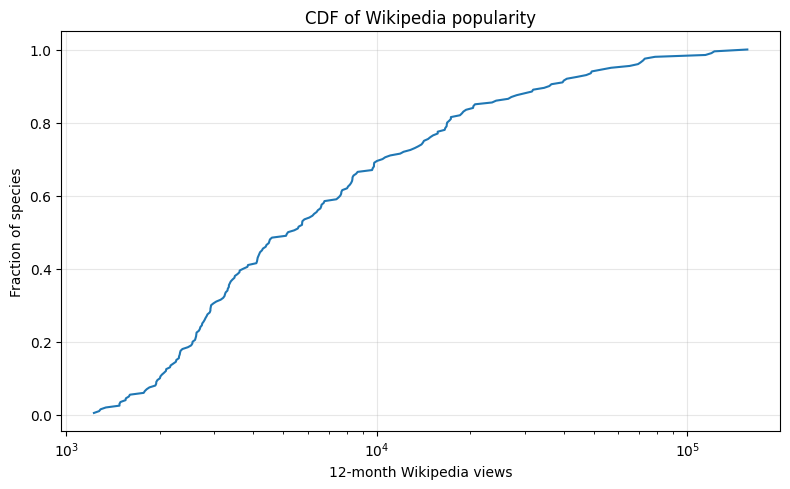

In [23]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
    .sort_values()
)

y = np.arange(1, len(popularity) + 1) / len(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(popularity, y)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("Fraction of species")
ax.set_title("CDF of Wikipedia popularity")

ax.grid(alpha=0.3)

print(popularity.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.tight_layout()
plt.show()

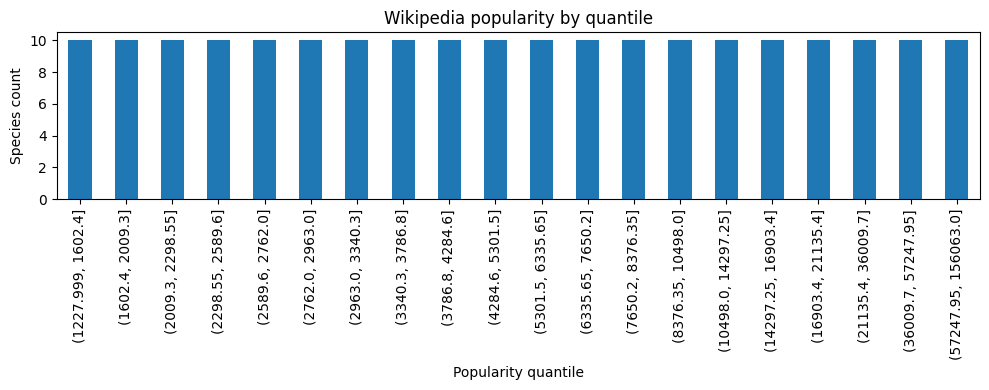

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

q = pd.qcut(popularity, q=20)

counts = q.value_counts(sort=False)

fig, ax = plt.subplots(figsize=(10, 4))

counts.plot.bar(ax=ax)

ax.set_ylabel("Species count")
ax.set_xlabel("Popularity quantile")
ax.set_title("Wikipedia popularity by quantile")

plt.tight_layout()
plt.show()

---
## 5 · Label selection & GeoJSON export

In [55]:
# Label: prefer main_common_name, fall back to scientific_name, then IUCN taxon ID.
common_label = df_wiki["main_common_name"].notna() & (df_wiki["main_common_name"] != "")
scientific_label = df_wiki["scientific_name"].notna() & (df_wiki["scientific_name"] != "")
df_wiki["label"] = "IUCN taxon " + df_wiki["taxonid"].astype(str)
df_wiki.loc[scientific_label, "label"] = df_wiki.loc[scientific_label, "scientific_name"]
df_wiki.loc[common_label, "label"] = df_wiki.loc[common_label, "main_common_name"].str.title()

# Drop species with 0 views (no Wikipedia presence → won't render usefully)
df_wiki = df_wiki[df_wiki.popularity > 0]

print(f"Final taxon count: {df_wiki.taxonid.nunique():,}")
print(f"Final points count: {len(df_wiki):,}")

Final taxon count: 200
Final points count: 224


In [56]:
# Build lightweight centroid GeoJSON used by the browser
features = []
required_geojson_cols = {"lon", "lat"}
missing_geojson_cols = required_geojson_cols - set(df_wiki.columns)
if missing_geojson_cols:
    raise RuntimeError(f"Missing centroid coordinate columns before GeoJSON export: {sorted(missing_geojson_cols)}. Rerun the spatial centroid merge cell before exporting.")
for _, row in df_wiki.iterrows():
    lon = clean_json_value(row["lon"])
    lat = clean_json_value(row["lat"])
    if lon is None or lat is None:
        continue
    props = feature_properties(row)
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [round(float(lon), 4), round(float(lat), 4)]
        },
        "properties": props
    })

geojson = {"type": "FeatureCollection", "features": features}

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
unique_taxa = len({f["properties"]["taxonid"] for f in features if (f.get("properties") or {}).get("taxonid") is not None})
print(f"Written: {OUTPUT_PATH} — {unique_taxa:,} taxa, {len(features):,} features, {size_mb:.1f} MB")
print(f"Run the merge cell to combine all per-mode files into {MERGED_OUTPUT_PATH}")



Written: data/processed/animals_sample_birds.geojson — 224 centroid features, 0.7 MB
Run the merge cell to combine all per-mode files into animals.geojson


### Merge per-mode files → animals.geojson

Combines all `animals_{mode}.geojson` files from `data/processed/` into the single `animals.geojson` file loaded by the globe.

In [60]:
import glob as _glob

per_mode_files = sorted(_glob.glob("data/processed/animals_*.geojson"))
if not per_mode_files:
    raise RuntimeError("No per-mode animals files found in data/processed/. Run the export cell for at least one mode.")

all_features = []
seen_taxon_centroids = set()
for path in per_mode_files:
    with open(path, encoding="utf-8") as f:
        gj = json.load(f)
    mode_features = gj.get("features", [])
    all_features.extend(mode_features)
    print(f"  {os.path.basename(path)}: {len(mode_features):,} features")

merged = {"type": "FeatureCollection", "features": all_features}
with open(MERGED_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(merged, f, ensure_ascii=False)

size_mb = os.path.getsize(MERGED_OUTPUT_PATH) / 1e6
unique_taxa = len({f["properties"]["taxonid"] for f in all_features if (f.get("properties") or {}).get("taxonid") is not None})
print(f"Merged {len(per_mode_files)} files → {MERGED_OUTPUT_PATH}: {unique_taxa:,} taxa, {len(all_features):,} features, {size_mb:.1f} MB")

  animals_sample.geojson: 252 features
  animals_sample_birds.geojson: 224 features
Merged 2 files → animals.geojson: 421 taxa, 476 features, 1.4 MB


### Sanity check

In [27]:
# Load back and inspect as a DataFrame
with open(OUTPUT_PATH, encoding="utf-8") as f:
    check = json.load(f)

records = []
for feat in check["features"]:
    props = dict(feat.get("properties") or {})
    geometry = feat.get("geometry") or {}
    coords = geometry.get("coordinates") or [None, None]
    props["geometry_type"] = geometry.get("type")
    props["lon"] = coords[0] if len(coords) > 0 else None
    props["lat"] = coords[1] if len(coords) > 1 else None
    records.append(props)

df_geojson = pd.DataFrame(records)
print(f"Loaded: {len(df_geojson):,} label points from {df_geojson['taxonid'].nunique():,} taxa")

preview_cols = [
    "taxonid", "label", "category_iucn", "taxon_class", "taxon_group",
    "centroid_rank", "centroid_count", "centroid_source", "popularity",
    "image_source", "image_lookup_source", "image_lookup_taxonid", "image_url", "wiki_url", "lat", "lon",
]
display(df_geojson[[col for col in preview_cols if col in df_geojson.columns]].head())

test = df_geojson[
    geojson_text_col(df_geojson, "label").str.casefold().eq("test")
]

print(f"Test rows: {len(test):,}")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 160):
    display(test.T if len(test) == 1 else test)


Loaded: 252 label points from 221 taxa


,taxonid,label,category_iucn,taxon_class,taxon_group,centroid_rank,centroid_count,centroid_source,popularity,image_source,image_lookup_source,image_lookup_taxonid,image_url,wiki_url,lat,lon
0,18,Bolivian Chinchilla Rat,CR,MAMMALIA,Mammals,1,1,range_polygon,2553,None,self,18,None,https://en.wikipedia.org/wiki/Bolivian_chinchi...,-17.9039,-64.5217
1,137,Sulawesi Fruit Bat,VU,MAMMALIA,Mammals,1,1,range_polygon,5381,Wikidata P18,self,137,https://commons.wikimedia.org/wiki/Special:Fil...,https://en.wikipedia.org/wiki/Sulawesi_flying_fox,-2.0808,121.2226
2,138,Talaud Fruit Bat,EN,MAMMALIA,Mammals,1,1,range_polygon,2233,Wikimedia Commons search,self,138,https://upload.wikimedia.org/wikipedia/commons...,https://en.wikipedia.org/wiki/Talaud_flying_fox,4.2711,126.8190
3,139,Golden-Capped Fruit Bat,EN,MAMMALIA,Mammals,1,1,range_polygon,305220,Wikidata P18,self,139,https://commons.wikimedia.org/wiki/Special:Fil...,https://en.wikipedia.org/wiki/Giant_golden-cro...,7.9901,122.9582
4,140,Palawan Fruit Bat,VU,MAMMALIA,Mammals,1,1,range_polygon,3738,None,self,140,None,https://en.wikipedia.org/wiki/Palawan_fruit_bat,9.8674,118.6340


Test rows: 0


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url,wiki_lookup_taxonid,wiki_lookup_source,wikipedia_thumbnail_url,commons_image_url,commons_image_page_url,commons_image_title,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,image_lookup_taxonid,image_lookup_source,label,category_iucn,population_trend,number_of_mature_individuals,estimated_area_of_occupancy,estimated_extent_of_occurrence,taxon_class,taxon_group,taxon_rank,parent_taxonid,child_infrarank_taxonids,iucn_has_ranges,iucn_has_points,centroid_source,centroid_rank,centroid_count,range_component_count,range_cluster_count,range_cluster_component_count,range_cluster_buffer_km,range_cluster_area_share,spatial_presence,spatial_presence_label,spatial_seasonal,spatial_seasonal_label,spatial_lookup_taxonid,spatial_lookup_source,computed_range_area_km2,computed_range_component_area_km2,range_component_area_km2,observation_point_count,source_paths,spatial_citation,spatial_year,spatial_credit,iucn_dataset_citation,iucn_data_last_updated,popularity,geometry_type,lon,lat


In [28]:
# Check cases with the same point
df_geojson[df_geojson[['lat','lon']].duplicated()]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,wiki_title,wiki_language,wiki_project,wiki_url,...,source_paths,spatial_citation,spatial_year,spatial_credit,iucn_dataset_citation,iucn_data_last_updated,popularity,geometry_type,lon,lat
49,2286,195990183,2020-02-18T00:00:00.000+00:00,2020,https://www.iucnredlist.org/species/2286/19599...,"Méndez-Carvajal, P.G. & Cortes-Ortíz, L. 2020....",Azuero_spider_monkey,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Azuero_spider_mo...,...,MAMMALS_PART2.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,2329,Point,-89.2878,15.8466
50,2289,17979560,2020-02-18T00:00:00.000+00:00,2020,https://www.iucnredlist.org/species/2289/17979560,"Solano-Rojas, D., Cortes-Ortíz, L. & Méndez-Ca...",Ornate_spider_monkey,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Ornate_spider_mo...,...,MAMMALS_PART2.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,4490,Point,-89.2878,15.8466
51,43901,17979679,2020-02-18T00:00:00.000+00:00,2020,https://www.iucnredlist.org/species/43901/1797...,"Williams-Guillén, K., Solano-Rojas, D. & Corte...",Nicaraguan_spider_monkey,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Nicaraguan_spide...,...,MAMMALS_PART2.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,3497,Point,-89.2878,15.8466
52,160872795,17979441,2020-02-18T00:00:00.000+00:00,2020,https://www.iucnredlist.org/species/160872795/...,"Rosales-Meda, M., Cortes-Ortíz, L., Canales-Es...",Mexican_spider_monkey,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Mexican_spider_m...,...,MAMMALS_PART2.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,16233,Point,-89.2878,15.8466
157,39317,45814320,2020-01-06T00:00:00.000+00:00,2020,https://www.iucnredlist.org/species/39317/4581...,"Emslie, R. 2020. Ceratotherium simum ssp. simu...",Southern_white_rhinoceros,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Southern_white_r...,...,MAMMALS_PART2.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,79103,Point,26.1034,-21.6624
158,39317,45814320,2020-01-06T00:00:00.000+00:00,2020,https://www.iucnredlist.org/species/39317/4581...,"Emslie, R. 2020. Ceratotherium simum ssp. simu...",Southern_white_rhinoceros,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Southern_white_r...,...,MAMMALS_PART2.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,79103,Point,36.2566,0.7541
166,40004,17984075,2018-11-05T00:00:00.000+00:00,2020,https://www.iucnredlist.org/species/40004/1798...,"Ikemeh, R., Oates, J.F. & Imong, I. 2020. Cerc...",Medjitol_(Cercopithecus_erythrogaster_pococki),avk,avk.wikipedia.org,https://avk.wikipedia.org/wiki/Medjitol_(Cerco...,...,MAMMALS_PART1.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,99,Point,4.7948,6.1685
168,136851,17984039,2017-07-27T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/136851/179...,"Etiendem, D., Imong, I., Gadsby, E.L. & Hofner...",Medjitol_(Cercopithecus_erythrotis_camerunensis),avk,avk.wikipedia.org,https://avk.wikipedia.org/wiki/Medjitol_(Cerco...,...,MAMMALS_PART1.shp,IUCN (International Union for Conservation of ...,2020,IUCN (International Union for Conservation of ...,IUCN 2

In [8]:
# Query Wikidata for Nilgiri Tahr only
# This mirrors the section 3 lookup, but keeps the one-animal result easy to inspect.
if "nilgiri_tahr" not in globals() or nilgiri_tahr.empty:
    with open(OUTPUT_PATH, encoding="utf-8") as f:
        check = json.load(f)
    nilgiri_records = [
        feat.get("properties") or {}
        for feat in check["features"]
        if str((feat.get("properties") or {}).get("label", "")).casefold() == "nilgiri tahr"
        or str((feat.get("properties") or {}).get("wiki_title", "")).casefold() == "nilgiri_tahr"
    ]
    nilgiri_tahr = pd.DataFrame(nilgiri_records)

if nilgiri_tahr.empty:
    raise ValueError("Nilgiri Tahr was not found in the browser GeoJSON output.")

nilgiri_taxonid = str(nilgiri_tahr.iloc[0]["taxonid"])
print(f"Nilgiri Tahr IUCN taxon ID: {nilgiri_taxonid}")

nilgiri_pipeline_lookup = query_wikidata_batch([nilgiri_taxonid], batch_size=1)
nilgiri_pipeline_result = nilgiri_pipeline_lookup.get(nilgiri_taxonid, {})
display(pd.Series(nilgiri_pipeline_result, name="section_3_selected_result").to_frame())

nilgiri_sparql = f"""
SELECT ?taxon ?taxonLabel ?iucn_id ?rankLabel ?wikidata_image_url ?article ?article_lang ?wiki_project ?article_title WHERE {{
  VALUES ?iucn_id {{ \"{nilgiri_taxonid}\" }}
  ?taxon wdt:P627 ?iucn_id .
  OPTIONAL {{ ?taxon wdt:P105 ?rank . }}
  OPTIONAL {{ ?taxon wdt:P18 ?wikidata_image_url . }}
  OPTIONAL {{
    ?article schema:about ?taxon ;
             schema:inLanguage ?article_lang ;
             schema:isPartOf ?wiki_site .
    FILTER(CONTAINS(STR(?wiki_site), \".wikipedia.org/\"))
    BIND(REPLACE(STR(?wiki_site), \"^https?://\", \"\") AS ?wiki_project_slash)
    BIND(REPLACE(?wiki_project_slash, \"/$\", \"\") AS ?wiki_project)
    BIND(REPLACE(STR(?article), CONCAT(\"https://\", ?wiki_project, \"/wiki/\"), \"\") AS ?article_title)
  }}
  SERVICE wikibase:label {{ bd:serviceParam wikibase:language \"en,fr,de,es\". }}
}}
ORDER BY ?article_lang
"""

r = requests.get(
    WIKIDATA_ENDPOINT,
    params={"query": nilgiri_sparql, "format": "json"},
    headers={"User-Agent": USER_AGENT},
    timeout=60,
)
r.raise_for_status()

nilgiri_wikidata_rows = []
for binding in r.json()["results"]["bindings"]:
    row = {key: value.get("value") for key, value in binding.items()}
    if row.get("article_title"):
        row["article_title"] = urllib.parse.unquote(row["article_title"])
    if row.get("wikidata_image_url"):
        row["wikidata_image_url"] = row["wikidata_image_url"].replace("http://", "https://", 1)
    nilgiri_wikidata_rows.append(row)

df_nilgiri_wikidata = pd.DataFrame(nilgiri_wikidata_rows)
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 180):
    display(df_nilgiri_wikidata)


Nilgiri Tahr IUCN taxon ID: 9917


Wikidata batches:   0%|          | 0/1 [00:00<?, ?it/s]

,section_3_selected_result
wiki_title,Nilgiri_tahr
wiki_language,en
wiki_project,en.wikipedia.org
wiki_url,https://en.wikipedia.org/wiki/Nilgiri_tahr
wiki_rank,0
wikidata_image_url,https://commons.wikimedia.org/wiki/Special:Fil...


,taxon,article,article_lang,wiki_project,article_title,iucn_id,wikidata_image_url,taxonLabel,rankLabel
0,http://www.wikidata.org/entity/Q22111959,https://br.wikipedia.org/wiki/Tahr_Nilgiri,br,br.wikipedia.org,Tahr_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
1,http://www.wikidata.org/entity/Q22111959,https://ca.wikipedia.org/wiki/Tar_dels_Nilgiri,ca,ca.wikipedia.org,Tar_dels_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
2,http://www.wikidata.org/entity/Q22111959,https://da.wikipedia.org/wiki/Nilgiritahr,da,da.wikipedia.org,Nilgiritahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
3,http://www.wikidata.org/entity/Q22111959,https://de.wikipedia.org/wiki/Nilgiri-Tahr,de,de.wikipedia.org,Nilgiri-Tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
4,http://www.wikidata.org/entity/Q22111959,https://en.wikipedia.org/wiki/Nilgiri_tahr,en,en.wikipedia.org,Nilgiri_tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
5,http://www.wikidata.org/entity/Q22111959,https://es.wikipedia.org/wiki/Nilgiritragus_hylocrius,es,es.wikipedia.org,Nilgiritragus_hylocrius,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
6,http://www.wikidata.org/entity/Q22111959,https://fr.wikipedia.org/wiki/Tahr_des_Nilgiri,fr,fr.wikipedia.org,Tahr_des_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
7,http://www.wikidata.org/entity/Q22111959,https://hu.wikipedia.org/wiki/Nilgiri_tahr,hu,hu.wikipedia.org,Nilgiri_tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
8,http://www.wikidata.org/entity/Q22111959,https://id.wikipedia.org/wiki/Tahr_nilgiri,id,id.wikipedia.org,Tahr_nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
9,http://www.wikidata.org/entity/Q22111959,https://it.wikipedia.org/wiki/Nilgiritragus_hylocrius,it,it.wikipedia.org,Nilgiritragus_hylocrius,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
